In [1]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.2 MB/s eta 0:00:00:00:0100:01


In [29]:
%%writefile train.py
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)

MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"

TRAIN_FILE = "/kaggle/input/datasets/nghia/ex3datasets/train.jsonl"
DEV_FILE = "/kaggle/input/datasets/nghia/ex3datasets/valid.jsonl"

OUTPUT_DIR = "/kaggle/working/qwen3_4b_kaggle_ddp_qlora"
RESUME_CHECKPOINT = "/kaggle/working/qwen3_4b_kaggle_ddp_qlora/checkpoint-2400"

MAX_LENGTH = 1024
PER_DEVICE_TRAIN_BATCH_SIZE = 1
PER_DEVICE_EVAL_BATCH_SIZE = 1
GRAD_ACC_STEPS = 16

# Nếu bạn đã xóa optimizer.pt/scaler.pt thì dùng LR này an toàn hơn
LEARNING_RATE = 6e-5

NUM_EPOCHS = 3

INSTRUCTION = (
    "Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt. "
    "Hãy đọc văn bản đầu vào và suy nghĩ, đánh giá kỹ lưỡng sau đó trả về đúng một JSON duy nhất theo định dạng: "
    "{\"Coherence\": <1-5>, \"Fluency\": <1-5>}. "
    "Chỉ trả về JSON, không giải thích thêm."
)


def build_tokenizer():
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        use_fast=True,
        trust_remote_code=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    tokenizer.padding_side = "right"
    return tokenizer


def preprocess_example(example, tokenizer):
    messages = example["messages"]

    if not isinstance(messages, list) or len(messages) < 2:
        raise ValueError(f"Sample không hợp lệ: {messages}")

    if messages[-1]["role"] != "assistant":
        raise ValueError(
            f"Message cuối phải là assistant, nhưng nhận được: {messages[-1]['role']}"
        )

    source_messages = messages[:-1]
    assistant_text = messages[-1].get("content", "").strip()

    input_chunks = []

    for msg in source_messages:
        if msg["role"] in ["user", "system"]:
            content = msg.get("content", "").strip()
            if content:
                input_chunks.append(content)

    input_text = "\n\n".join(input_chunks)

    final_user_messages = [
        {
            "role": "user",
            "content": f"{INSTRUCTION}\n\nVăn bản cần đánh giá:\n{input_text}",
        }
    ]

    prompt_text = tokenizer.apply_chat_template(
        final_user_messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    full_messages = final_user_messages + [
        {
            "role": "assistant",
            "content": assistant_text,
        }
    ]

    full_text = tokenizer.apply_chat_template(
        full_messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    prompt_tokens = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        add_special_tokens=False,
    )

    full_tokens = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        add_special_tokens=False,
    )

    input_ids = full_tokens["input_ids"]
    attention_mask = full_tokens["attention_mask"]

    prompt_len = len(prompt_tokens["input_ids"])

    labels = [-100] * prompt_len + input_ids[prompt_len:]
    labels = labels[:len(input_ids)]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }


def build_dataset(tokenizer):
    raw_datasets = load_dataset(
        "json",
        data_files={
            "train": TRAIN_FILE,
            "validation": DEV_FILE,
        },
    )

    remove_cols = raw_datasets["train"].column_names

    tokenized_datasets = raw_datasets.map(
        lambda example: preprocess_example(example, tokenizer),
        remove_columns=remove_cols,
        num_proc=1,
        desc="Tokenizing and masking assistant response only",
    )

    return tokenized_datasets


def build_model(local_rank):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.float16,
    )

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        torch_dtype=torch.float16,
        device_map={"": local_rank},
        trust_remote_code=True,
    )

    model.config.use_cache = False

    model = prepare_model_for_kbit_training(model)

    try:
        model.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={"use_reentrant": False}
        )
    except TypeError:
        model.gradient_checkpointing_enable()

    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=32,
        lora_alpha=64,
        lora_dropout=0.02,
        bias="none",
        target_modules=[
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
    )

    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    return model


def main():
    local_rank = int(os.environ.get("LOCAL_RANK", 0))

    if torch.cuda.is_available():
        torch.cuda.set_device(local_rank)

    tokenizer = build_tokenizer()
    tokenized_datasets = build_dataset(tokenizer)

    model = build_model(local_rank)

    data_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer,
        model=None,
        padding=True,
        pad_to_multiple_of=8,
        label_pad_token_id=-100,
        return_tensors="pt",
    )

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,

        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,

        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACC_STEPS,

        fp16=True,
        bf16=False,

        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},

        # Dùng cái này nếu bạn đã xóa optimizer.pt/scaler.pt
        optim="adamw_torch",

        remove_unused_columns=False,
        group_by_length=True,

        dataloader_num_workers=0,
        dataloader_pin_memory=False,

        logging_strategy="steps",
        logging_steps=20,
        logging_first_step=True,

        eval_strategy="steps",
        eval_steps=400,

        save_strategy="steps",
        save_steps=400,
        save_total_limit=2,

        lr_scheduler_type="cosine",
        warmup_ratio=0.03,

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        ddp_find_unused_parameters=False,

        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
    )

    trainer.train(resume_from_checkpoint=RESUME_CHECKPOINT)

    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)


if __name__ == "__main__":
    main()

Overwriting train.py


In [30]:

!rm -f /kaggle/working/qwen3_4b_kaggle_ddp_qlora/checkpoint-2400/optimizer.pt
!rm -f /kaggle/working/qwen3_4b_kaggle_ddp_qlora/checkpoint-2400/scaler.pt

In [31]:
!CUDA_VISIBLE_DEVICES=0,1 accelerate launch \
  --multi_gpu \
  --num_processes 2 \
  --mixed_precision fp16 \
  train.py

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|█| 398/398 [00:09<00:00, 42.71it/s, Materializing param=mo
Loading weights: 100%|█| 398/398 [00:09<00:00, 42.12it/s, Materializing param=mo
trainable params: 66,060,288 || all params: 4,088,528,384 || trainable%: 1.6157
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
trainable params

In [36]:
log_history = trainer.state.log_history
train_steps = []
train_losses = []

eval_steps = []
eval_losses = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
        
    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_losses.append(log["eval_loss"])

NameError: name 'trainer' is not defined

In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
# trainer_state
trainer_state_path = "/kaggle/working/qwen3_4b_kaggle_ddp_qlora/checkpoint-3720/trainer_state.json"

with open(trainer_state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

log_history = trainer_state["log_history"]

train_logs = []
eval_logs = []

for log in log_history:
    step = log.get("step")

    if "loss" in log:
        train_logs.append({
            "step": step,
            "epoch": log.get("epoch"),
            "train_loss": log["loss"],
            "learning_rate": log.get("learning_rate"),
            "grad_norm": log.get("grad_norm"),
        })

    if "eval_loss" in log:
        eval_logs.append({
            "step": step,
            "epoch": log.get("epoch"),
            "eval_loss": log["eval_loss"],
            "eval_runtime": log.get("eval_runtime"),
        })

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

print("Train loss:")
display(train_df.head())
display(train_df.tail())

print("Eval loss:")
display(eval_df)

Train loss:


,step,epoch,train_loss,learning_rate,grad_norm
0,20,0.016139,0.710857,0.000032,0.644899
1,40,0.032278,0.113899,0.000068,0.160860
2,60,0.048416,0.103366,0.000104,0.271473
3,80,0.064555,0.102453,0.000139,0.213896
4,100,0.080694,0.101319,0.000175,0.470384


,step,epoch,train_loss,learning_rate,grad_norm
181,3640,2.936050,0.071073,0.000047,0.158993
182,3660,2.952189,0.065673,0.000046,0.151648
183,3680,2.968328,0.065457,0.000046,0.116591
184,3700,2.984466,0.071711,0.000045,0.236179
185,3720,3.000000,0.065711,0.000045,0.235215


Eval loss:


,step,epoch,eval_loss,eval_runtime
0,400,0.322776,0.099599,932.4691
1,800,0.645552,0.090193,938.1248
2,1200,0.968328,0.087194,929.8673
3,1600,1.290498,0.085298,935.9154
4,2000,1.613274,0.083313,933.5853
5,2400,1.936050,0.082858,937.3959
6,2800,2.258221,0.078599,784.6169
7,3200,2.580997,0.078123,784.8585
8,3600,2.903772,0.077278,816.2609


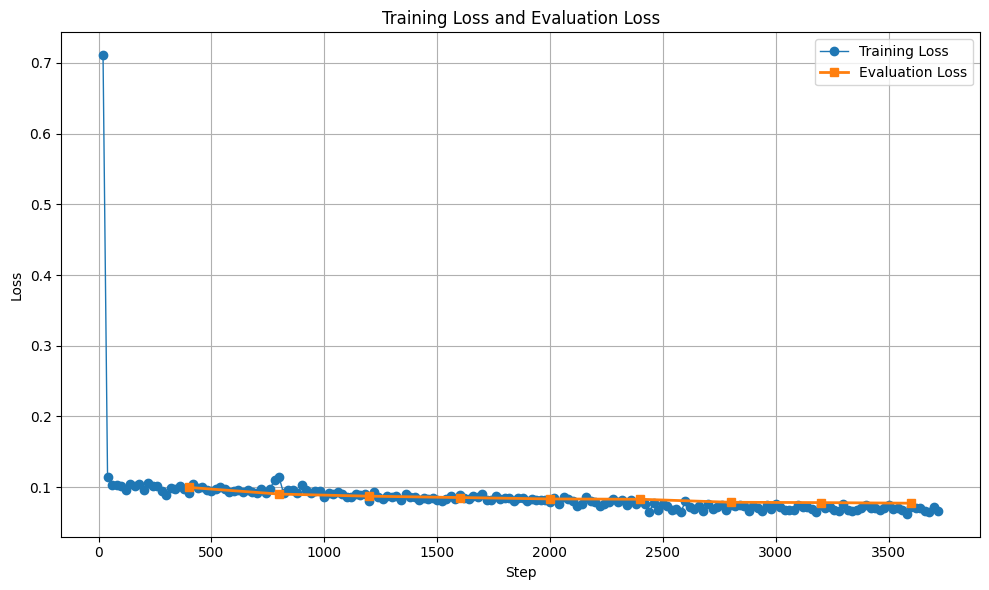

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_df["step"],
    train_df["train_loss"],
    marker="o",
    linewidth=1,
    label="Training Loss"
)

plt.plot(
    eval_df["step"],
    eval_df["eval_loss"],
    marker="s",
    linewidth=2,
    label="Evaluation Loss"
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss and Evaluation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("/kaggle/working/loss_curve.png", dpi=300)
plt.show()

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# model gốc (base model)
base_model_name = "Qwen/Qwen3-4B-Instruct-2507"

# thư mục chứa adapter LoRA sau khi train
lora_path = "/kaggle/input/models/trongtr/adapter-rank32-qwen3/pytorch/default/1"

# load base model 
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    use_fast=True,
    trust_remote_code=True,
  
)
# gắn LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    lora_path
)

# chuyển sang eval mode
model.eval()


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2560)
        (layers): ModuleList(
          (0-35): 36 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2560, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.02, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [3]:
from sklearn.metrics import f1_score, mean_absolute_error, cohen_kappa_score
import pandas as pd
import json
import re
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
DEFAULT_INSTRUCTION = (
     "Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt. "
    "Hãy đọc văn bản đầu vào và suy nghĩ , đánh giá kỹ lưỡng sau đó trả về đúng một JSON duy nhất theo định dạng: "
    "{\"Coherence\": <1-5>, \"Fluency\": <1-5>}. "
    "Chỉ trả về JSON, không giải thích thêm."
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


# Load test dataset

raw_datasets = load_dataset(
    "json",
    data_files={
        "test": "/kaggle/input/datasets/trongtr/ex3datasets/test (4).jsonl"
    },
)

def clamp_score(x):
    try:
        x = int(x)
        return min(5, max(1, x))
    except:
        return 1

def parse_label(text):
    if not text:
        return {"coherence": 1, "fluency": 1}

    text = text.strip()

    # parse JSON 
    try:
        obj = json.loads(text)
        return {
            "coherence": clamp_score(obj.get("Coherence", obj.get("coherence", 1))),
            "fluency": clamp_score(obj.get("Fluency", obj.get("fluency", 1))),
        }
    except:
        pass

    # fallback regex
    coh = re.search(r'"?(?:Coherence|coherence)"?\s*:\s*(\d+)', text)
    flu = re.search(r'"?(?:Fluency|fluency)"?\s*:\s*(\d+)', text)

    return {
        "coherence": clamp_score(coh.group(1)) if coh else 1,
        "fluency": clamp_score(flu.group(1)) if flu else 1,
    }

def build_input_text(example):
    messages = example["messages"]
    source_messages = messages[:-1]

    input_chunks = []
    for msg in source_messages:
        if msg["role"] in ["user", "system"]:
            content = msg.get("content", "").strip()
            if content:
                input_chunks.append(content)

    return "\n\n".join(input_chunks)

def get_gold_label(example):
    assistant_text = example["messages"][-1].get("content", "").strip()
    return parse_label(assistant_text)

def predict_label(input_text, max_new_tokens=64):
    messages = [
        {
            "role": "user",
            "content": f"{DEFAULT_INSTRUCTION}\n\nVăn bản cần đánh giá:\n{input_text}"
        }
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    pred_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return parse_label(pred_text), pred_text
# Evaluation
def evaluate_testset(dataset):
    total = 0
    correct_coherence = 0
    correct_fluency = 0
    exact_both = 0

    gold_coherence_list = []
    pred_coherence_list = []
    gold_fluency_list = []
    pred_fluency_list = []

    results = []

    for idx, example in enumerate(dataset):
        input_text = build_input_text(example)
        gold = get_gold_label(example)
        pred, raw_pred_text = predict_label(input_text)

        gold_coh = gold["coherence"]
        gold_flu = gold["fluency"]
        pred_coh = pred["coherence"]
        pred_flu = pred["fluency"]

        coh_ok = int(pred_coh == gold_coh)
        flu_ok = int(pred_flu == gold_flu)
        both_ok = int(coh_ok and flu_ok)

        total += 1
        correct_coherence += coh_ok
        correct_fluency += flu_ok
        exact_both += both_ok

        gold_coherence_list.append(gold_coh)
        pred_coherence_list.append(pred_coh)
        gold_fluency_list.append(gold_flu)
        pred_fluency_list.append(pred_flu)

        print(f"\n========== SAMPLE {idx} ==========")
        print(f"GOLD LABEL:")
        print(f"  coherence = {gold_coh}")
        print(f"  fluency   = {gold_flu}")
        print(f"PREDICTED LABEL:")
        print(f"  coherence = {pred_coh}")
        print(f"  fluency   = {pred_flu}")
        print(f"CHECK:")
        print(f"  coherence_correct = {coh_ok}")
        print(f"  fluency_correct   = {flu_ok}")
        print(f"  exact_both        = {both_ok}")
        print(f"RAW MODEL OUTPUT:")
        print(raw_pred_text)
        print("=" * 35)

        results.append({
            "text": input_text,

            "gold_coherence": gold_coh,
            "pred_coherence": pred_coh,
            "coherence_correct": coh_ok,

            "gold_fluency": gold_flu,
            "pred_fluency": pred_flu,
            "fluency_correct": flu_ok,

            "exact_both": both_ok,
            "raw_pred_text": raw_pred_text,
        })

    labels = [1, 2, 3, 4, 5]

    metrics = {
        "total": total,

        # Accuracy
        "coherence_accuracy": correct_coherence / total if total > 0 else 0.0,
        "fluency_accuracy": correct_fluency / total if total > 0 else 0.0,
        "exact_both_accuracy": exact_both / total if total > 0 else 0.0,

        # F1-score
        "coherence_f1_macro": f1_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            average="macro",
            zero_division=0,
        ),
        "fluency_f1_macro": f1_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            average="macro",
            zero_division=0,
        ),

        "coherence_f1_weighted": f1_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            average="weighted",
            zero_division=0,
        ),
        "fluency_f1_weighted": f1_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            average="weighted",
            zero_division=0,
        ),

        # MAE
        "coherence_mae": mean_absolute_error(
            gold_coherence_list,
            pred_coherence_list,
        ),
        "fluency_mae": mean_absolute_error(
            gold_fluency_list,
            pred_fluency_list,
        ),

        # Quadratic Weighted Kappa
        "coherence_qwk": cohen_kappa_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            weights="quadratic",
        ),
        "fluency_qwk": cohen_kappa_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            weights="quadratic",
        ),
    }

    return metrics, results


# =========================
# Run
# =========================
metrics, results = evaluate_testset(raw_datasets["test"])

print("\n===== EVAL RESULT =====")
print(f"Total samples              : {metrics['total']}")

print("\n--- Accuracy ---")
print(f"Coherence accuracy         : {metrics['coherence_accuracy']:.4f}")
print(f"Fluency accuracy           : {metrics['fluency_accuracy']:.4f}")
print(f"Exact both accuracy        : {metrics['exact_both_accuracy']:.4f}")

print("\n--- F1-score ---")
print(f"Coherence F1-macro         : {metrics['coherence_f1_macro']:.4f}")
print(f"Fluency F1-macro           : {metrics['fluency_f1_macro']:.4f}")
print(f"Coherence F1-weighted      : {metrics['coherence_f1_weighted']:.4f}")
print(f"Fluency F1-weighted        : {metrics['fluency_f1_weighted']:.4f}")

print("\n--- MAE ---")
print(f"Coherence MAE              : {metrics['coherence_mae']:.4f}")
print(f"Fluency MAE                : {metrics['fluency_mae']:.4f}")

print("\n--- Quadratic Weighted Kappa ---")
print(f"Coherence QWK              : {metrics['coherence_qwk']:.4f}")
print(f"Fluency QWK                : {metrics['fluency_qwk']:.4f}")


results_df = pd.DataFrame(results)
results_df.to_csv("eval_results_with_metrics.csv", index=False)

print("\nSaved detail results to: eval_results_with_metrics.csv")


========== SAMPLE 0 ==========
GOLD LABEL:
  coherence = 5
  fluency   = 5
PREDICTED LABEL:
  coherence = 4
  fluency   = 4
CHECK:
  coherence_correct = 0
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 4, "Fluency": 4}

========== SAMPLE 1 ==========
GOLD LABEL:
  coherence = 4
  fluency   = 4
PREDICTED LABEL:
  coherence = 4
  fluency   = 4
CHECK:
  coherence_correct = 1
  fluency_correct   = 1
  exact_both        = 1
RAW MODEL OUTPUT:
{"Coherence": 4, "Fluency": 4}

========== SAMPLE 2 ==========
GOLD LABEL:
  coherence = 4
  fluency   = 4
PREDICTED LABEL:
  coherence = 4
  fluency   = 4
CHECK:
  coherence_correct = 1
  fluency_correct   = 1
  exact_both        = 1
RAW MODEL OUTPUT:
{"Coherence": 4, "Fluency": 4}

========== SAMPLE 3 ==========
GOLD LABEL:
  coherence = 2
  fluency   = 1
PREDICTED LABEL:
  coherence = 2
  fluency   = 2
CHECK:
  coherence_correct = 1
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 2, "F

In [11]:
#Load file đánh giá
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# =========================
# Load CSV result file
# =========================
csv_path = "/kaggle/input/datasets/trongtr/eval-metrics/eval_results_with_metrics.csv"
results_df = pd.read_csv(csv_path)

labels = [1, 2, 3, 4, 5]

# =========================
# Recompute metrics
# =========================
metrics = {
    "total": len(results_df),

    "coherence_accuracy": accuracy_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
    ),
    "fluency_accuracy": accuracy_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
    ),
    "exact_both_accuracy": results_df["exact_both"].mean(),

    "coherence_f1_macro": f1_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        average="macro",
        zero_division=0,
    ),
    "fluency_f1_macro": f1_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        average="macro",
        zero_division=0,
    ),

    "coherence_f1_weighted": f1_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        average="weighted",
        zero_division=0,
    ),
    "fluency_f1_weighted": f1_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        average="weighted",
        zero_division=0,
    ),

    "coherence_mae": mean_absolute_error(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
    ),
    "fluency_mae": mean_absolute_error(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
    ),

    "coherence_qwk": cohen_kappa_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        weights="quadratic",
    ),
    "fluency_qwk": cohen_kappa_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        weights="quadratic",
    ),
}

# =========================
# Print metrics
# =========================
print("===== EVAL RESULT FROM CSV =====")
print(f"Total samples              : {metrics['total']}")

print("\n--- Accuracy ---")
print(f"Coherence accuracy         : {metrics['coherence_accuracy']:.4f}")
print(f"Fluency accuracy           : {metrics['fluency_accuracy']:.4f}")
print(f"Exact both accuracy        : {metrics['exact_both_accuracy']:.4f}")

print("\n--- F1-score ---")
print(f"Coherence F1-macro         : {metrics['coherence_f1_macro']:.4f}")
print(f"Fluency F1-macro           : {metrics['fluency_f1_macro']:.4f}")
print(f"Coherence F1-weighted      : {metrics['coherence_f1_weighted']:.4f}")
print(f"Fluency F1-weighted        : {metrics['fluency_f1_weighted']:.4f}")

print("\n--- MAE ---")
print(f"Coherence MAE              : {metrics['coherence_mae']:.4f}")
print(f"Fluency MAE                : {metrics['fluency_mae']:.4f}")

print("\n--- Quadratic Weighted Kappa ---")
print(f"Coherence QWK              : {metrics['coherence_qwk']:.4f}")
print(f"Fluency QWK                : {metrics['fluency_qwk']:.4f}")


===== EVAL RESULT FROM CSV =====
Total samples              : 6964

--- Accuracy ---
Coherence accuracy         : 0.6466
Fluency accuracy           : 0.6152
Exact both accuracy        : 0.5111

--- F1-score ---
Coherence F1-macro         : 0.6172
Fluency F1-macro           : 0.6023
Coherence F1-weighted      : 0.6399
Fluency F1-weighted        : 0.6095

--- MAE ---
Coherence MAE              : 0.3903
Fluency MAE                : 0.4238

--- Quadratic Weighted Kappa ---
Coherence QWK              : 0.8943
Fluency QWK                : 0.8828


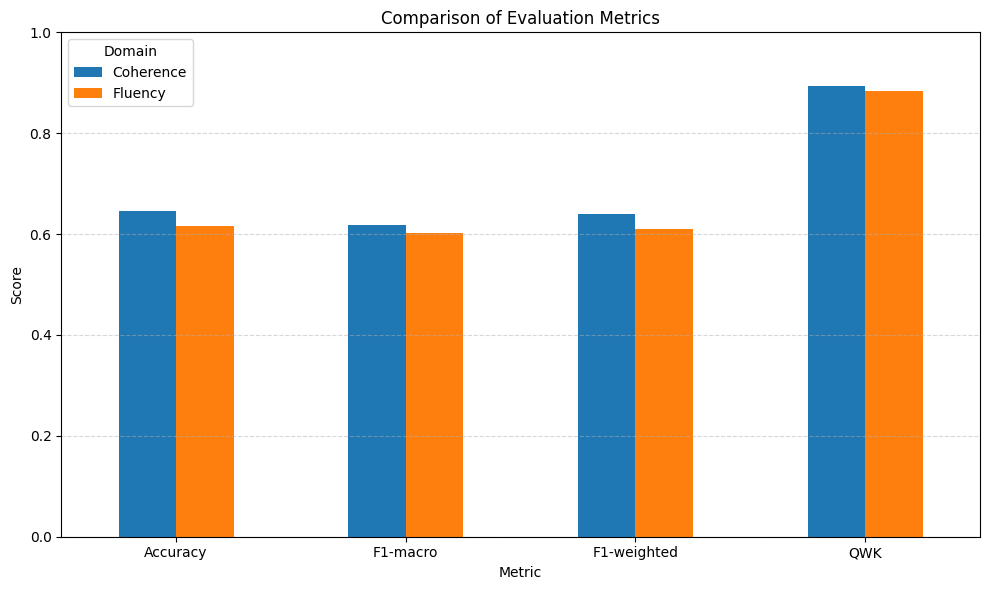

In [12]:
metric_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1-macro", "F1-weighted", "QWK"],
    "Coherence": [
        metrics["coherence_accuracy"],
        metrics["coherence_f1_macro"],
        metrics["coherence_f1_weighted"],
        metrics["coherence_qwk"],
    ],
    "Fluency": [
        metrics["fluency_accuracy"],
        metrics["fluency_f1_macro"],
        metrics["fluency_f1_weighted"],
        metrics["fluency_qwk"],
    ],
})

metric_df.set_index("Metric").plot(kind="bar", figsize=(10, 6))

plt.title("Comparison of Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Domain")
plt.tight_layout()
plt.show()

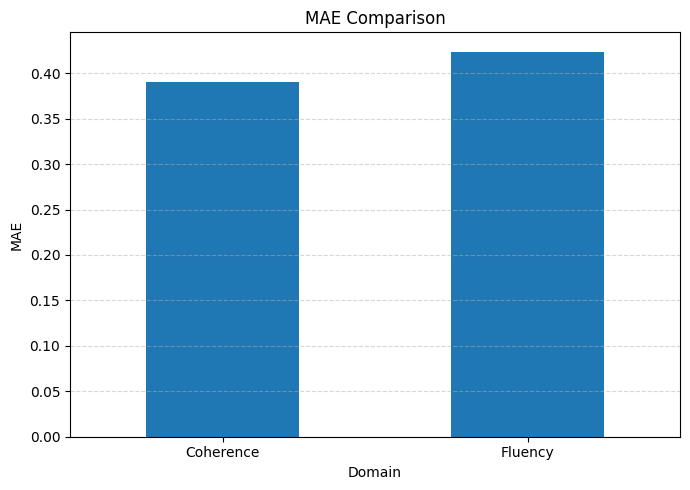

In [13]:
mae_df = pd.DataFrame({
    "Domain": ["Coherence", "Fluency"],
    "MAE": [
        metrics["coherence_mae"],
        metrics["fluency_mae"],
    ],
})

mae_df.plot(
    kind="bar",
    x="Domain",
    y="MAE",
    figsize=(7, 5),
    legend=False,
)

plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xlabel("Domain")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

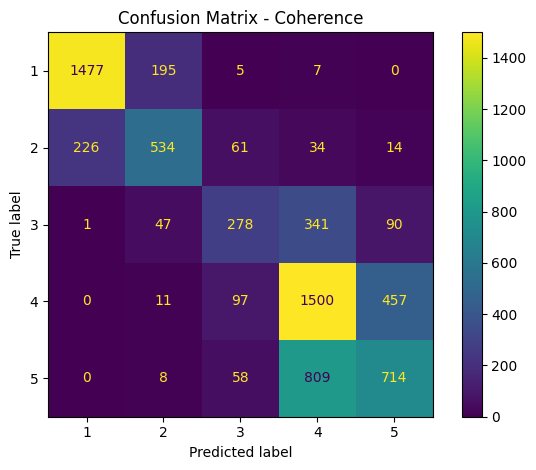

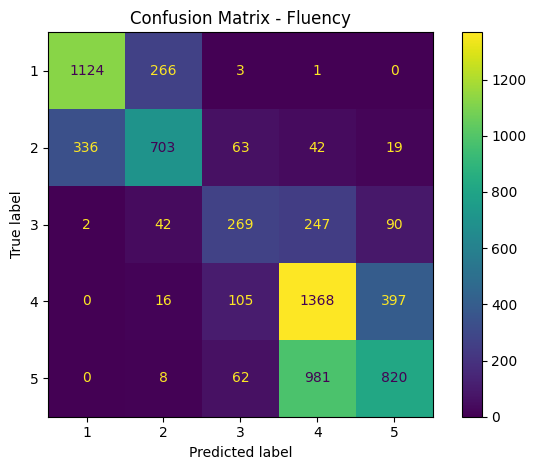

In [14]:
cm_coh = confusion_matrix(
    results_df["gold_coherence"],
    results_df["pred_coherence"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_coh,
    display_labels=labels,
)

disp.plot()
plt.title("Confusion Matrix - Coherence")
plt.tight_layout()
plt.show()


cm_flu = confusion_matrix(
    results_df["gold_fluency"],
    results_df["pred_fluency"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_flu,
    display_labels=labels,
)

disp.plot()
plt.title("Confusion Matrix - Fluency")
plt.tight_layout()
plt.show()

In [37]:
import zipfile
import os

def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                
                # giữ cấu trúc thư mục
                arcname = os.path.relpath(file_path, folder_path)
                
                zipf.write(file_path, arcname)

# path adapter
folder_to_zip = "/kaggle/working/qwen3_4b_kaggle_ddp_qlora/checkpoint-3720"
zip_file = "adapter_qwen3_4b_checkpoint-3720.zip"

zip_folder(folder_to_zip, zip_file)

print("Zip completed:", zip_file)

Zip completed: adapter_qwen3_4b_checkpoint-3720.zip


***Base Model without Adapter***

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# model gốc (base model)
base_model_name = "Qwen/Qwen3-4B-Instruct-2507"

# thư mục chứa adapter LoRA sau khi train

# load base model 
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name,
    use_fast=True,
    trust_remote_code=True,
  
)
# # gắn LoRA adapter
# model = PeftModel.from_pretrained(
#     base_model,
#     lora_path
# )

# chuyển sang eval mode
base_model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 2560)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=2560, out_features=4096, bias=False)
          (k_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2560, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=2560, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (up_proj): Linear(in_features=2560, out_features=9728, bias=False)
          (down_proj): Linear(in_features=9728, out_features=2560, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((2560,), eps=1e-06)
        (post_attention_layer

In [4]:
from sklearn.metrics import f1_score, mean_absolute_error, cohen_kappa_score
import pandas as pd
import json
import re
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
DEFAULT_INSTRUCTION = (
     "Bạn là chuyên gia đánh giá chất lượng văn bản tiếng Việt. "
    "Hãy đọc văn bản đầu vào và suy nghĩ , đánh giá kỹ lưỡng sau đó trả về đúng một JSON duy nhất theo định dạng: "
    "{\"Coherence\": <1-5>, \"Fluency\": <1-5>}. "
    "Chỉ trả về JSON, không giải thích thêm."
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# =========================
# Load test dataset
# =========================
raw_datasets = load_dataset(
    "json",
    data_files={
        "test": "/kaggle/input/datasets/trongtr/ex3datasets/test (4).jsonl"
    },
)

# =========================
# Utils
# =========================
def clamp_score(x):
    try:
        x = int(x)
        return min(5, max(1, x))
    except:
        return 1

def parse_label(text):
    if not text:
        return {"coherence": 1, "fluency": 1}

    text = text.strip()

    # thử parse JSON trực tiếp
    try:
        obj = json.loads(text)
        return {
            "coherence": clamp_score(obj.get("Coherence", obj.get("coherence", 1))),
            "fluency": clamp_score(obj.get("Fluency", obj.get("fluency", 1))),
        }
    except:
        pass

    # fallback regex
    coh = re.search(r'"?(?:Coherence|coherence)"?\s*:\s*(\d+)', text)
    flu = re.search(r'"?(?:Fluency|fluency)"?\s*:\s*(\d+)', text)

    return {
        "coherence": clamp_score(coh.group(1)) if coh else 1,
        "fluency": clamp_score(flu.group(1)) if flu else 1,
    }

def build_input_text(example):
    messages = example["messages"]
    source_messages = messages[:-1]

    input_chunks = []
    for msg in source_messages:
        if msg["role"] in ["user", "system"]:
            content = msg.get("content", "").strip()
            if content:
                input_chunks.append(content)

    return "\n\n".join(input_chunks)

def get_gold_label(example):
    assistant_text = example["messages"][-1].get("content", "").strip()
    return parse_label(assistant_text)

def predict_label(input_text, max_new_tokens=64):
    messages = [
        {
            "role": "user",
            "content": f"{DEFAULT_INSTRUCTION}\n\nVăn bản cần đánh giá:\n{input_text}"
        }
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(prompt_text, return_tensors="pt").to(base_model.device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    pred_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return parse_label(pred_text), pred_text

# =========================
# Evaluation
# =========================
def evaluate_testset(dataset):
    total = 0
    correct_coherence = 0
    correct_fluency = 0
    exact_both = 0

    gold_coherence_list = []
    pred_coherence_list = []
    gold_fluency_list = []
    pred_fluency_list = []

    results = []

    for idx, example in enumerate(dataset):
        input_text = build_input_text(example)
        gold = get_gold_label(example)
        pred, raw_pred_text = predict_label(input_text)

        gold_coh = gold["coherence"]
        gold_flu = gold["fluency"]
        pred_coh = pred["coherence"]
        pred_flu = pred["fluency"]

        coh_ok = int(pred_coh == gold_coh)
        flu_ok = int(pred_flu == gold_flu)
        both_ok = int(coh_ok and flu_ok)

        total += 1
        correct_coherence += coh_ok
        correct_fluency += flu_ok
        exact_both += both_ok

        gold_coherence_list.append(gold_coh)
        pred_coherence_list.append(pred_coh)
        gold_fluency_list.append(gold_flu)
        pred_fluency_list.append(pred_flu)

        print(f"\n========== SAMPLE {idx} ==========")
        print(f"GOLD LABEL:")
        print(f"  coherence = {gold_coh}")
        print(f"  fluency   = {gold_flu}")
        print(f"PREDICTED LABEL:")
        print(f"  coherence = {pred_coh}")
        print(f"  fluency   = {pred_flu}")
        print(f"CHECK:")
        print(f"  coherence_correct = {coh_ok}")
        print(f"  fluency_correct   = {flu_ok}")
        print(f"  exact_both        = {both_ok}")
        print(f"RAW MODEL OUTPUT:")
        print(raw_pred_text)
        print("=" * 35)

        results.append({
            "text": input_text,

            "gold_coherence": gold_coh,
            "pred_coherence": pred_coh,
            "coherence_correct": coh_ok,

            "gold_fluency": gold_flu,
            "pred_fluency": pred_flu,
            "fluency_correct": flu_ok,

            "exact_both": both_ok,
            "raw_pred_text": raw_pred_text,
        })

    labels = [1, 2, 3, 4, 5]

    metrics = {
        "total": total,

        # Accuracy
        "coherence_accuracy": correct_coherence / total if total > 0 else 0.0,
        "fluency_accuracy": correct_fluency / total if total > 0 else 0.0,
        "exact_both_accuracy": exact_both / total if total > 0 else 0.0,

        # F1-score
        "coherence_f1_macro": f1_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            average="macro",
            zero_division=0,
        ),
        "fluency_f1_macro": f1_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            average="macro",
            zero_division=0,
        ),

        "coherence_f1_weighted": f1_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            average="weighted",
            zero_division=0,
        ),
        "fluency_f1_weighted": f1_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            average="weighted",
            zero_division=0,
        ),

        # MAE
        "coherence_mae": mean_absolute_error(
            gold_coherence_list,
            pred_coherence_list,
        ),
        "fluency_mae": mean_absolute_error(
            gold_fluency_list,
            pred_fluency_list,
        ),

        # Quadratic Weighted Kappa
        "coherence_qwk": cohen_kappa_score(
            gold_coherence_list,
            pred_coherence_list,
            labels=labels,
            weights="quadratic",
        ),
        "fluency_qwk": cohen_kappa_score(
            gold_fluency_list,
            pred_fluency_list,
            labels=labels,
            weights="quadratic",
        ),
    }

    return metrics, results


# =========================
# Run
# =========================
metrics, results = evaluate_testset(raw_datasets["test"])

print("\n===== EVAL RESULT =====")
print(f"Total samples              : {metrics['total']}")

print("\n--- Accuracy ---")
print(f"Coherence accuracy         : {metrics['coherence_accuracy']:.4f}")
print(f"Fluency accuracy           : {metrics['fluency_accuracy']:.4f}")
print(f"Exact both accuracy        : {metrics['exact_both_accuracy']:.4f}")

print("\n--- F1-score ---")
print(f"Coherence F1-macro         : {metrics['coherence_f1_macro']:.4f}")
print(f"Fluency F1-macro           : {metrics['fluency_f1_macro']:.4f}")
print(f"Coherence F1-weighted      : {metrics['coherence_f1_weighted']:.4f}")
print(f"Fluency F1-weighted        : {metrics['fluency_f1_weighted']:.4f}")

print("\n--- MAE ---")
print(f"Coherence MAE              : {metrics['coherence_mae']:.4f}")
print(f"Fluency MAE                : {metrics['fluency_mae']:.4f}")

print("\n--- Quadratic Weighted Kappa ---")
print(f"Coherence QWK              : {metrics['coherence_qwk']:.4f}")
print(f"Fluency QWK                : {metrics['fluency_qwk']:.4f}")


# Optional: lưu kết quả từng mẫu ra CSV để phân tích sau
results_df = pd.DataFrame(results)
results_df.to_csv("eval_results_with_metrics.csv", index=False)

print("\nSaved detail results to: eval_results_with_metrics.csv")

Generating test split: 0 examples [00:00, ? examples/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



========== SAMPLE 0 ==========
GOLD LABEL:
  coherence = 5
  fluency   = 5
PREDICTED LABEL:
  coherence = 4
  fluency   = 3
CHECK:
  coherence_correct = 0
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 4, "Fluency": 3}

========== SAMPLE 1 ==========
GOLD LABEL:
  coherence = 4
  fluency   = 4
PREDICTED LABEL:
  coherence = 5
  fluency   = 5
CHECK:
  coherence_correct = 0
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 5, "Fluency": 5}

========== SAMPLE 2 ==========
GOLD LABEL:
  coherence = 4
  fluency   = 4
PREDICTED LABEL:
  coherence = 5
  fluency   = 5
CHECK:
  coherence_correct = 0
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 5, "Fluency": 5}

========== SAMPLE 3 ==========
GOLD LABEL:
  coherence = 2
  fluency   = 1
PREDICTED LABEL:
  coherence = 3
  fluency   = 2
CHECK:
  coherence_correct = 0
  fluency_correct   = 0
  exact_both        = 0
RAW MODEL OUTPUT:
{"Coherence": 3, "F

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# =========================
# Load CSV result file
# =========================
csv_path = "/kaggle/working/eval_results_with_metrics.csv"
results_df = pd.read_csv(csv_path)

labels = [1, 2, 3, 4, 5]

# =========================
# Recompute metrics
# =========================
metrics = {
    "total": len(results_df),

    "coherence_accuracy": accuracy_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
    ),
    "fluency_accuracy": accuracy_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
    ),
    "exact_both_accuracy": results_df["exact_both"].mean(),

    "coherence_f1_macro": f1_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        average="macro",
        zero_division=0,
    ),
    "fluency_f1_macro": f1_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        average="macro",
        zero_division=0,
    ),

    "coherence_f1_weighted": f1_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        average="weighted",
        zero_division=0,
    ),
    "fluency_f1_weighted": f1_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        average="weighted",
        zero_division=0,
    ),

    "coherence_mae": mean_absolute_error(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
    ),
    "fluency_mae": mean_absolute_error(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
    ),

    "coherence_qwk": cohen_kappa_score(
        results_df["gold_coherence"],
        results_df["pred_coherence"],
        labels=labels,
        weights="quadratic",
    ),
    "fluency_qwk": cohen_kappa_score(
        results_df["gold_fluency"],
        results_df["pred_fluency"],
        labels=labels,
        weights="quadratic",
    ),
}

# =========================
# Print metrics
# =========================
print("===== EVAL RESULT FROM CSV =====")
print(f"Total samples              : {metrics['total']}")

print("\n--- Accuracy ---")
print(f"Coherence accuracy         : {metrics['coherence_accuracy']:.4f}")
print(f"Fluency accuracy           : {metrics['fluency_accuracy']:.4f}")
print(f"Exact both accuracy        : {metrics['exact_both_accuracy']:.4f}")

print("\n--- F1-score ---")
print(f"Coherence F1-macro         : {metrics['coherence_f1_macro']:.4f}")
print(f"Fluency F1-macro           : {metrics['fluency_f1_macro']:.4f}")
print(f"Coherence F1-weighted      : {metrics['coherence_f1_weighted']:.4f}")
print(f"Fluency F1-weighted        : {metrics['fluency_f1_weighted']:.4f}")

print("\n--- MAE ---")
print(f"Coherence MAE              : {metrics['coherence_mae']:.4f}")
print(f"Fluency MAE                : {metrics['fluency_mae']:.4f}")

print("\n--- Quadratic Weighted Kappa ---")
print(f"Coherence QWK              : {metrics['coherence_qwk']:.4f}")
print(f"Fluency QWK                : {metrics['fluency_qwk']:.4f}")

===== EVAL RESULT FROM CSV =====
Total samples              : 6964

--- Accuracy ---
Coherence accuracy         : 0.3077
Fluency accuracy           : 0.3824
Exact both accuracy        : 0.1643

--- F1-score ---
Coherence F1-macro         : 0.2579
Fluency F1-macro           : 0.3285
Coherence F1-weighted      : 0.2515
Fluency F1-weighted        : 0.3510

--- MAE ---
Coherence MAE              : 0.9088
Fluency MAE                : 0.8359

--- Quadratic Weighted Kappa ---
Coherence QWK              : 0.6711
Fluency QWK                : 0.7200


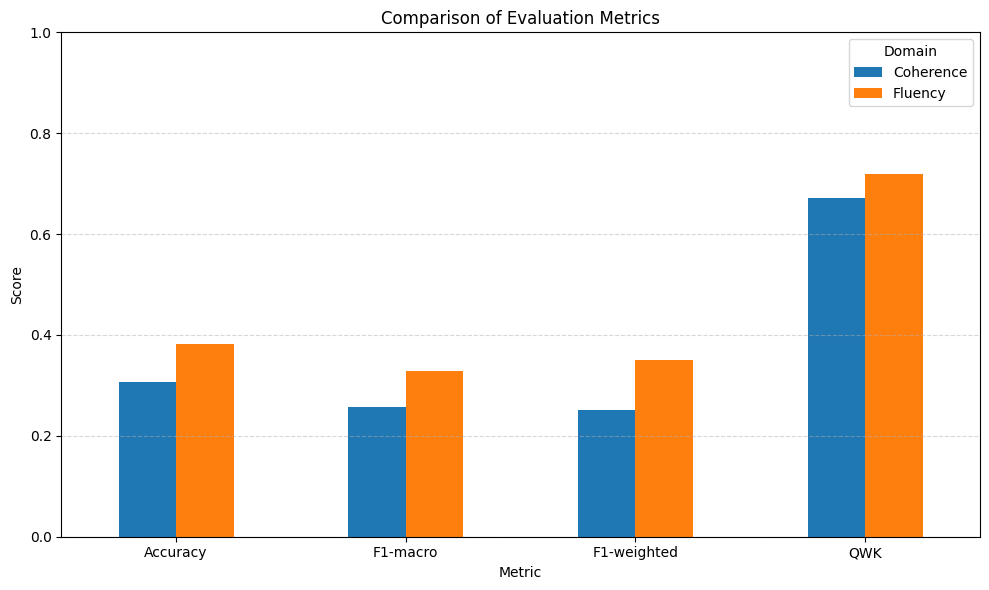

In [6]:
metric_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1-macro", "F1-weighted", "QWK"],
    "Coherence": [
        metrics["coherence_accuracy"],
        metrics["coherence_f1_macro"],
        metrics["coherence_f1_weighted"],
        metrics["coherence_qwk"],
    ],
    "Fluency": [
        metrics["fluency_accuracy"],
        metrics["fluency_f1_macro"],
        metrics["fluency_f1_weighted"],
        metrics["fluency_qwk"],
    ],
})

metric_df.set_index("Metric").plot(kind="bar", figsize=(10, 6))

plt.title("Comparison of Evaluation Metrics")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Domain")
plt.tight_layout()
plt.show()

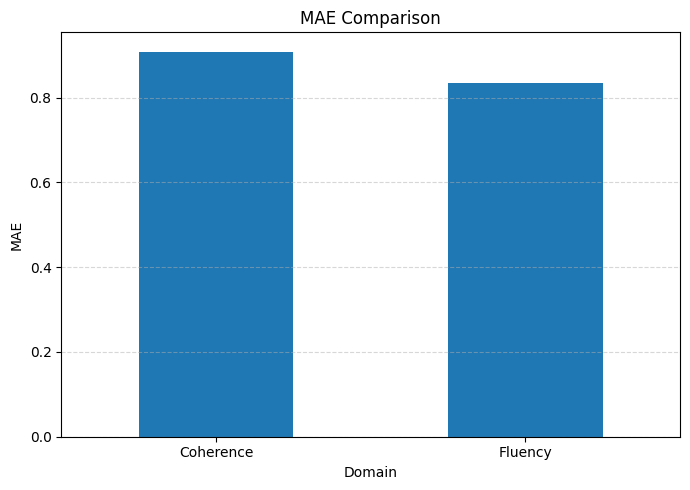

In [8]:
mae_df = pd.DataFrame({
    "Domain": ["Coherence", "Fluency"],
    "MAE": [
        metrics["coherence_mae"],
        metrics["fluency_mae"],
    ],
})

mae_df.plot(
    kind="bar",
    x="Domain",
    y="MAE",
    figsize=(7, 5),
    legend=False,
)

plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xlabel("Domain")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

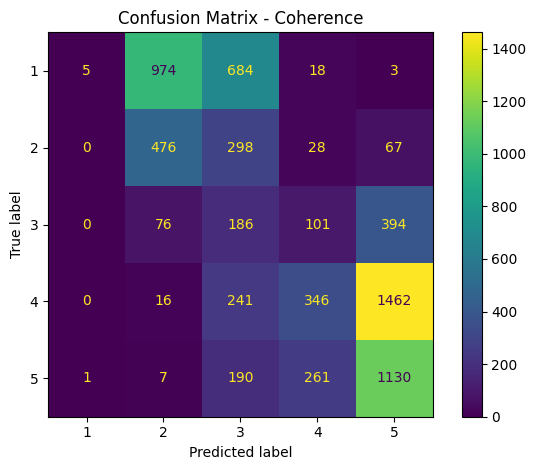

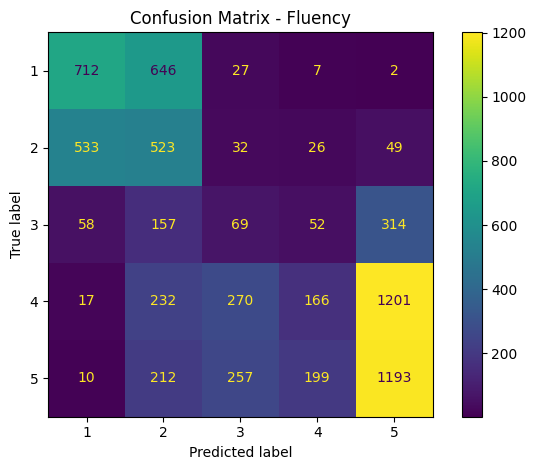

In [9]:
cm_coh = confusion_matrix(
    results_df["gold_coherence"],
    results_df["pred_coherence"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_coh,
    display_labels=labels,
)

disp.plot()
plt.title("Confusion Matrix - Coherence")
plt.tight_layout()
plt.show()


cm_flu = confusion_matrix(
    results_df["gold_fluency"],
    results_df["pred_fluency"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_flu,
    display_labels=labels,
)

disp.plot()
plt.title("Confusion Matrix - Fluency")
plt.tight_layout()
plt.show()

In [38]:
from IPython.display import FileLink
# Giả sử file của bạn tên là 'result.zip' và nằm trong /kaggle/working
FileLink(r'adapter_qwen3_4b_checkpoint-3720.zip')

/kaggle/working/adapter_qwen3_4b_checkpoint-3720.zip